In [56]:
#Data Load Preparation
import pandas as pd
df=pd.read_csv("C:/Users/DELL/Desktop/ml-assessment-Ashish_Kashid_bitsom_ba-2511333/data/q3_retail_promotions.csv")
df.head()

,transaction_date,store_id,store_size,location_type,promotion_type,is_weekend,is_festival,competition_density,items_sold
0,2022-01-01,28,small,semi-urban,free_gift,1,0,5,224
1,2022-01-01,5,medium,semi-urban,free_gift,1,1,1,348
2,2022-01-02,13,small,semi-urban,loyalty_points,1,0,6,249
3,2022-01-02,17,small,urban,free_gift,1,0,7,259
4,2022-01-03,50,medium,semi-urban,bogo,0,0,3,277


In [57]:
#Date feature engineering
df['transaction_date'] = pd.to_datetime(df['transaction_date'])
df['Year'] = df['transaction_date'].dt.year
df['Month'] = df['transaction_date'].dt.month
df['Day'] = df['transaction_date'].dt.day
#Month end feature
df['Is_Month_End'] = 0
df.loc[df['transaction_date'].dt.day >=25, 'Is_Month_End'] = 1
df.head()

,transaction_date,store_id,store_size,location_type,promotion_type,is_weekend,is_festival,competition_density,items_sold,Year,Month,Day,Is_Month_End
0,2022-01-01,28,small,semi-urban,free_gift,1,0,5,224,2022,1,1,0
1,2022-01-01,5,medium,semi-urban,free_gift,1,1,1,348,2022,1,1,0
2,2022-01-02,13,small,semi-urban,loyalty_points,1,0,6,249,2022,1,2,0
3,2022-01-02,17,small,urban,free_gift,1,0,7,259,2022,1,2,0
4,2022-01-03,50,medium,semi-urban,bogo,0,0,3,277,2022,1,3,0


In [58]:
df.isnull().sum()

transaction_date       0
store_id               0
store_size             0
location_type          0
promotion_type         0
is_weekend             0
is_festival            0
competition_density    0
items_sold             0
Year                   0
Month                  0
Day                    0
Is_Month_End           0
dtype: int64

In [59]:
#Temporal feature engineering
#Date Sorting
df = df.sort_values(by='transaction_date')
#Split index for train and test
split_index = int(len(df) * 0.8)
train_df = df.iloc[:split_index]
test_df = df.iloc[split_index:]
print("Train set shape:", train_df.shape)
print("Test set shape:", test_df.shape)
# Train and test sets
X_train = train_df.drop(columns=['items_sold', 'transaction_date'])
y_train = train_df['items_sold']
X_test = test_df.drop(columns=['items_sold', 'transaction_date'])
y_test = test_df['items_sold']



Train set shape: (960, 13)
Test set shape: (240, 13)


# A random split is inappropriate for time-order data as there is chance of mixing of past date & future date data.Due this model may learn from future date data, which is not acceptable.In real life we always use past date data to predict future data. So we split data based on time & take past date data for model training purpose and latest date data for test purpose.

In [60]:
print(X_train.head())

   store_id store_size location_type  promotion_type  is_weekend  is_festival  \
0        28      small    semi-urban       free_gift           1            0   
1         5     medium    semi-urban       free_gift           1            1   
2        13      small    semi-urban  loyalty_points           1            0   
3        17      small         urban       free_gift           1            0   
4        50     medium    semi-urban            bogo           0            0   

   competition_density  Year  Month  Day  Is_Month_End  
0                    5  2022      1    1             0  
1                    1  2022      1    1             0  
2                    6  2022      1    2             0  
3                    7  2022      1    2             0  
4                    3  2022      1    3             0  


In [61]:
#Preprocessing Pipeline
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
#Numerical and categorical features
numerical_features = ['store_id','is_weekend','is_festival','competition_density','Year','Month','Day','Is_Month_End']
categorical_features = ['store_size', 'promotion_type', 'location_type']
#Preprocessing for numerical and categorical features
prprocessing_pipeline = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numerical_features),
    ('cat', OneHotEncoder(), categorical_features)
])


In [62]:
#Model Training and Evaluation
#Linear Regression
from sklearn.linear_model import LinearRegression
lr_pipeline = Pipeline(steps=[
    ('preprocessor', prprocessing_pipeline),
    ('regressor', LinearRegression())
])
lr_pipeline.fit(X_train, y_train)
y_pred_lr = lr_pipeline.predict(X_test)

#Random Forest Regressor
from sklearn.ensemble import RandomForestRegressor
rf_pipeline = Pipeline(steps=[
    ('preprocessor', prprocessing_pipeline),
    ('regressor', RandomForestRegressor(n_estimators=100, random_state=42))
])
rf_pipeline.fit(X_train, y_train)
y_pred_rf = rf_pipeline.predict(X_test)

In [63]:
#Model Training and Evaluation
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

#Linear Regression Evaluation
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
mae_lr = mean_absolute_error(y_test, y_pred_lr)
print("Linear Regression - RMSE:", rmse_lr)
print("Linear Regression - MAE:", mae_lr)
#Random Forest Regressor Evaluation
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mae_rf = mean_absolute_error(y_test, y_pred_rf)
print("Random Forest Regressor - RMSE:", rmse_rf)
print("Random Forest Regressor - MAE:", mae_rf)


Linear Regression - RMSE: 27.12182923945292
Linear Regression - MAE: 21.052073125062105
Random Forest Regressor - RMSE: 30.070855567863934
Random Forest Regressor - MAE: 23.415541666666666


# From above readings Linear regression model performs better than Random Forest model, as it has lower RMSE and MAE values. So, we can conclude that linear regression model which captures the pattern efficiently. 

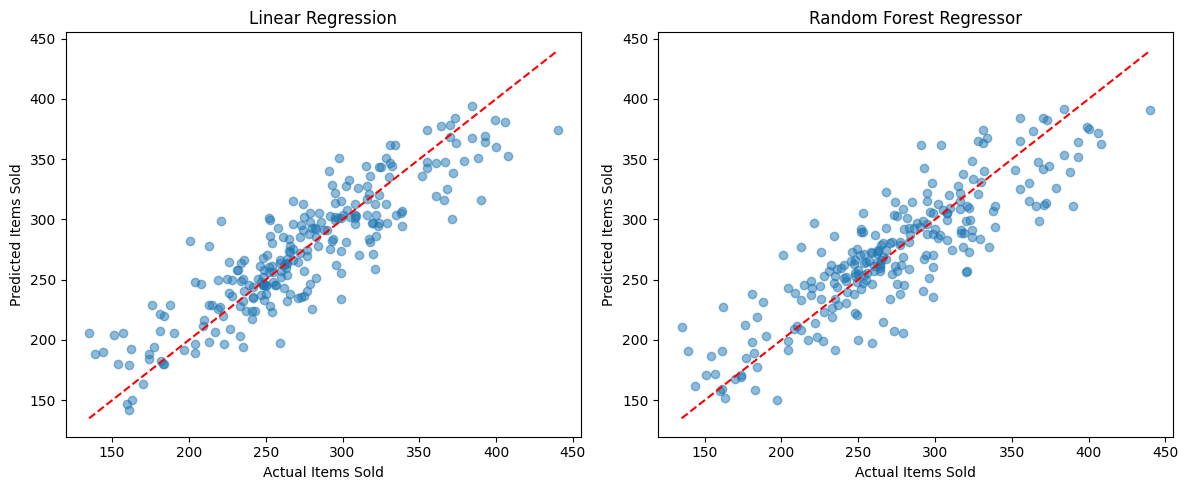

In [64]:
#Parity plot (predicted vs actual items_sold) for each model, with a diagonal reference line
import matplotlib.pyplot as plt
# Parity plot for Linear Regression
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.scatter(y_test, y_pred_lr, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')  # Diagonal reference line
plt.xlabel('Actual Items Sold')
plt.ylabel('Predicted Items Sold')
plt.title('Linear Regression')

# Parity plot for Random Forest Regressor
plt.subplot(1, 2, 2)
plt.scatter(y_test, y_pred_rf, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')  # Diagonal reference line
plt.xlabel('Actual Items Sold')
plt.ylabel('Predicted Items Sold')
plt.title('Random Forest Regressor')
plt.tight_layout()
plt.show()


# From both graphs we can understand predicted values are mostly close to actual values by considering diagonal reference line.But Linear regression shows slightly better visualization hence we can say that it is better model out of two.

In [65]:
#Print the feature importances from the Random Forest and identify the top 5 most influential features
#Extracting feature importances from the Random Forest model
rf_model = rf_pipeline.named_steps['regressor']
encoded_feature_names = rf_pipeline.named_steps['preprocessor'].transformers_[1][1].get_feature_names_out(categorical_features)
all_feature_names = numerical_features + list(encoded_feature_names)
feature_importances = rf_model.feature_importances_
feature_names = all_feature_names

# Create a DataFrame for better visualization
importance_df = pd.DataFrame({'feature': feature_names, 'importance': feature_importances})
importance_df = importance_df.sort_values('importance', ascending=False)

# Display the top 5 most influential features
print("Top 5 Most Influential Features:")
print(importance_df.head(5))

Top 5 Most Influential Features:
                feature  importance
2           is_festival    0.173304
10     store_size_small    0.166786
1            is_weekend    0.127292
18  location_type_urban    0.108051
16  location_type_rural    0.052779


# Above observation shows sales is strongly affected with above top 5 featured mainly catogorise in two groups i.e. time based & store characterstics like location and size. Management can take consideration of this to make stratergy to get more profit by optimizing the resources. 